# **Uber EDA and Clustering Analysis**

This notebook performs exploratory data analysis (EDA) and clustering on Uber's 2014 and 2015 pickup data. It covers data preparation, K-Means clustering, correlation analysis, and linear regression. Key visualizations and insights are included.

---



# **1. Introduction**

##**a. Uber Platform Overview**

**Core Business Model**
- Uber operates a two-sided marketplace connecting riders and drivers.
- Uses a centralized system for automated matching and pricing.

**Platform Components**
1. Driver App: Allows drivers to offer services and communicate with riders.
2. Rider App: Enables booking, journey tracking, and vehicle selection.
3. Dispatch System: Connects drivers and riders via mobile devices.

**Key Performance Advantages**
- Higher Efficiency: Improved capacity utilization rates compared to traditional taxis.
- Lower Wait Times: Riders experience shorter waiting times compared to street-hailing.
- Better Matching: Optimized driver-rider matching using advanced algorithms.

**Critical Platform Functions**
1. Matching Algorithms:
   - Matches riders to drivers efficiently.
   - Uses batching to consolidate multiple ride requests for improved matching.
2. Dynamic Pricing (Surge Pricing):
   - Balances supply and demand by adjusting prices in real-time.
   - Known as "surge pricing" (Uber) or "prime time" (Lyft).



## **b. NYC Pickup Dataset Details**

**Data Source**
- Sourced from FiveThirtyEight’s GitHub repository.
- Obtained via Freedom of Information Law (FOIL) request to NYC Taxi & Limousine Commission.

**Dataset Coverage**
- 2014: Over 4.5 million Uber pickups (April–September).
- 2015: Over 14.3 million Uber pickups (January–June).
- Data spans all five NYC boroughs.

**Variables**

2014 Data:
- Date/Time: Timestamp of the pickup.
- Lat/Lon: Pickup latitude and longitude.
- Base: TLC base company code.

2015 Data:
- Dispatching_base_num: Base that dispatched the Uber.
- Pickup_date: Timestamp of the pickup.
- Affiliated_base_num: TLC base code.
- locationID: Pickup location identifier.

**Base Codes**
Key Uber bases included in the dataset:
- B02512: Unter
- B02598: Hinter
- B02617: Weiter
- B02682: Schmecken
- B02764: Danach-NY
- B02765: Grun
- B02836: Drinnen



## **c. Objective and Scope**

**Objective:**

Analyze Uber’s 2014 and 2015 pickup data to uncover:
- Trip patterns and demand peaks.
- Insights into location-based behaviors.

**Scope:**
1. Perform K-Means clustering to group pickup locations.
2. Explore temporal and spatial patterns in trip data.
3. Use linear regression to identify significant predictors of trip demand.

---

#**2. Uber NYC Pickup Data Preparation**


**Dataset Overview:**
The dataset contains Uber pickup data in NYC with the following fields:
- Pickup datetime: Timestamp of each ride.
- Pickup location: Latitude and longitude of the pickup.
- Other features: Additional metrics related to the ride (if applicable).

**Objective:**
- Explore data distributions.
- Identify key trends in ride demand.
- Uncover patterns based on time, location, and rider behavior.


##**a. Import Libraries**


In [ ]:
# System Operations and Time Handling
import os                  # File/directory operations
import time               # Time functions
from datetime import datetime  # Date/time handling

# Data Science & Analysis
import numpy as np        # Numerical computing
import pandas as pd       # Data manipulation
import seaborn as sns     # Statistical visualization
import matplotlib.pyplot as plt  # Plotting
# plt.style.use('ggplot')    # Optional: Plot styling

# Machine Learning & Statistics
import sklearn           # ML tools
import statsmodels.api as sm  # Statistical modeling
import tensorflow as tf   # Deep learning
# tf.keras.utils.set_random_seed(42)  # Optional: Random seed

# Google Colab Setup
from google.colab import drive  # Mount Google Drive
drive.mount('/content/drive')   # Connect to Drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##**b. Data Processing**



In [ ]:
# Set data paths
data_path = '/content/drive/yourpath'
uber_2015_path = os.path.join(data_path, 'Uber_Trip_Data_2015')
uber_2014_path = os.path.join(data_path, 'Uber_Trip_Data_2014')

# List directory contents
os.listdir(data_path)
os.listdir(uber_2015_path)
sorted(os.listdir(uber_2014_path))

# Load and process 2015 data
uber_2015_pickup_data = pd.read_csv(os.path.join(uber_2015_path, 'uber-raw-data-janjune-15.csv'))
uber_2015_pickup_data['Date'] = pd.to_datetime(uber_2015_pickup_data['Pickup_date']).dt.date

# Load and process 2014 data
uber_2014_pickup_data = []
for csv_path in os.listdir(uber_2014_path)[:-1]:
    df = pd.read_csv(os.path.join(uber_2014_path, csv_path))
    uber_2014_pickup_data.append(df)
uber_2014_pickup_data = pd.concat(uber_2014_pickup_data, axis=0)

# Process datetime columns for 2014 data
uber_2014_pickup_data['Date/Time'] = pd.to_datetime(uber_2014_pickup_data['Date/Time'], format='mixed') # Using format='mixed' to handle potential variations in datetime formats across the dataset
uber_2014_pickup_data['Date'] = pd.to_datetime(uber_2014_pickup_data['Date/Time']).dt.date
uber_2014_pickup_data['Time'] = pd.to_datetime(uber_2014_pickup_data['Date/Time']).dt.time

# # Save combined 2014 dataset
# uber_2014_pickup_data.to_csv(os.path.join(uber_2014_path, 'uber-raw-data-2014.csv'), index=False)

##**c. Data Exploration**

    This section imports and loads the NYC Uber pickup data into a Pandas DataFrame. Basic exploration is conducted to:
    - Inspect the first few rows of data.
    - Understand the structure and completeness of the dataset.
    - Identify missing or invalid values for preprocessing.

In [ ]:
# Basic exploration of 2015 data
uber_2015_pickup_data.head()
uber_2015_pickup_data.shape
uber_2015_pickup_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14270479 entries, 0 to 14270478
Data columns (total 5 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   Dispatching_base_num  object
 1   Pickup_date           object
 2   Affiliated_base_num   object
 3   locationID            int64 
 4   Date                  object
dtypes: int64(1), object(4)
memory usage: 544.4+ MB


In [ ]:
# Basic exploration of 2014 data
uber_2014_pickup_data.head()
uber_2014_pickup_data.shape
uber_2014_pickup_data.info()
uber_2014_pickup_data.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 4534327 entries, 0 to 1028135
Data columns (total 6 columns):
 #   Column     Dtype         
---  ------     -----         
 0   Date/Time  datetime64[ns]
 1   Lat        float64       
 2   Lon        float64       
 3   Base       object        
 4   Date       object        
 5   Time       object        
dtypes: datetime64[ns](1), float64(2), object(3)
memory usage: 242.2+ MB


,0
Date/Time,0
Lat,0
Lon,0
Base,0
Date,0
Time,0


---

#**3. Feature Engineering & Exploratory Data Analysis (EDA) for Uber Pickup Data**

##**a. Creating Time-Based Features**

    Creating new features for further analysis such as hourly pickups or weekday vs. weekend analysis.

    Key Features Created:

    - Month: Captures monthly patterns (1-12)
    - Week: ISO week number of the year
    - DayOfMonthNum: Day of month (1-31)
    - DayOfWeekNum: Day of week (0-6, Monday=0)
    - DayOfWeek: Name of weekday
    - Hour: Hour of day (0-23)

In [ ]:
# Defining a function to convert datetime columns and extract relevant information

def add_date_features(df, datetime_column):
    """
    Add time-based features to a dataframe containing a datetime column

    Parameters:
    df (pandas.DataFrame): Input dataframe
    datetime_column (str): Name of datetime column

    Returns:
    pandas.DataFrame: DataFrame with additional time-based features
    """
    # Ensure datetime column is in correct format
    df[datetime_column] = pd.to_datetime(df[datetime_column])

    # Extract time-based features
    df['Month'] = df[datetime_column].dt.month # Month Number (e.g., April = 4)
    df['Week'] = df[datetime_column].dt.isocalendar().week # Week Number
    df['DayOfMonthNum'] = df[datetime_column].dt.day # Day number in a month
    df['DayOfWeekNum'] = df[datetime_column].dt.dayofweek # Numeric day (0=Monday, 6=Sunday)
    df['DayOfWeek'] = df[datetime_column].dt.day_name() # Day name
    df['Hour'] = df[datetime_column].dt.hour # Hour of the day

    return df


In [ ]:
# Apply feature engineering to 2014 dataset
uber_2014_pickup_data = add_date_features(uber_2014_pickup_data, 'Date/Time')

# Apply feature engineering to 2015 dataset
uber_2015_pickup_data = add_date_features(uber_2015_pickup_data, 'Pickup_date')

##**b. Temporal Trip Patterns**

    Objectives:
    - Analyze ride demand patterns over time.
    - Visualize trends to understand how demand changes throughout the day, week, or year.


###**i. Rides Per Month**
    - Determining the total number of pickups per month in the 2014 and 2015 sample.

2014 Monthly Counts:


,Rides Count
Month,
4,564516
5,652435
6,663844
7,796121
8,829275
9,1028136



2015 Monthly Counts:


,Rides Count
Month,
1,1873186
2,2182040
3,2259773
4,2280837
5,2695553
6,2816895


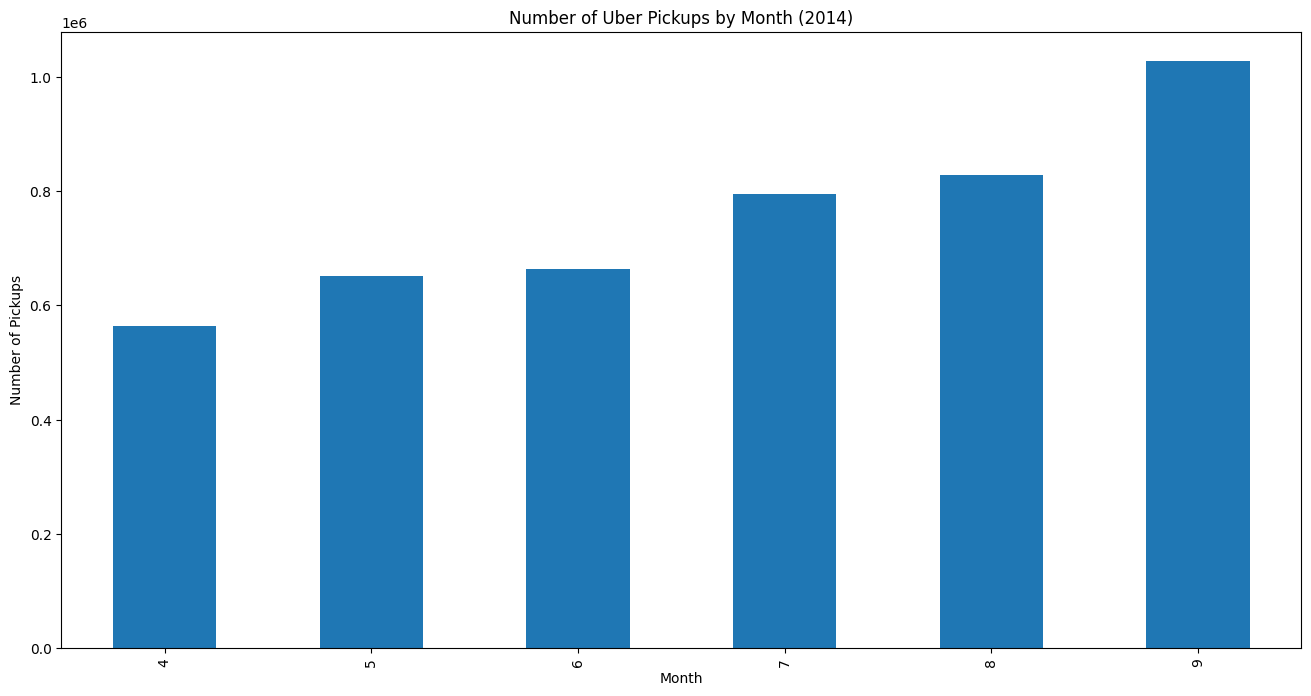

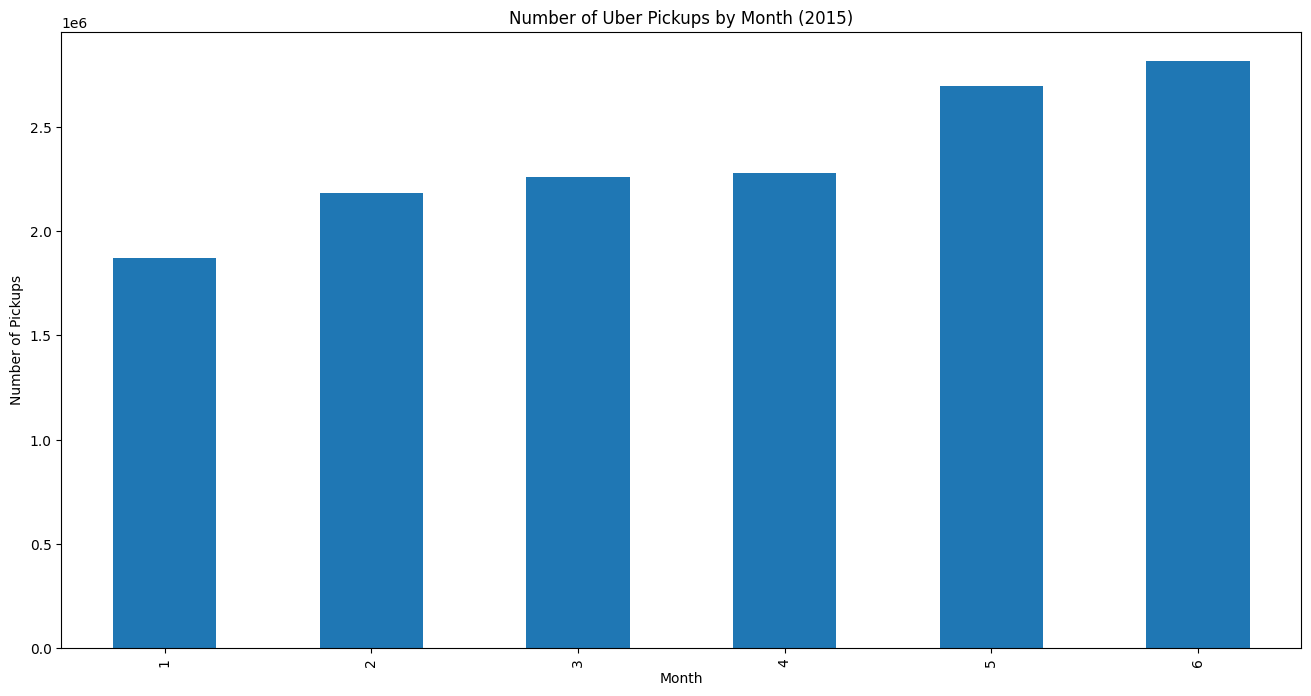

In [ ]:
# 1. Create monthly aggregations
monthly_rides_2014 = uber_2014_pickup_data.groupby('Month')['Base'].count().rename('Rides Count')
monthly_rides_2015 = uber_2015_pickup_data.groupby('Month')['Affiliated_base_num'].count().rename('Rides Count')

# 2. Display raw monthly counts for both years
print("2014 Monthly Counts:")
display(monthly_rides_2014)
print("\n2015 Monthly Counts:")
display(monthly_rides_2015)

# 3. Create visualizations
# 2014 Plot
monthly_rides_2014.plot(
    kind='bar',
    figsize=(16,8),
    title='Number of Uber Pickups by Month (2014)',
    xlabel='Month',
    ylabel='Number of Pickups'
)
plt.show()

# 2015 Plot
monthly_rides_2015.plot(
    kind='bar',
    figsize=(16,8),
    title='Number of Uber Pickups by Month (2015)',
    xlabel='Month',
    ylabel='Number of Pickups'
)
plt.show()

    Key Insights:
    - A steady increase in rides over months suggests growth or demand changes.
    - Differences between 2014 and 2015 can highlight market expansion or external factors like weather.

###**ii. Rides Per Day**
    - Finding for the days which had more total pickups, and how the number of pickups compare across days.

2014 Daily Counts:


,Rides Count
DayOfWeek,
Monday,541472
Tuesday,663789
Wednesday,696488
Thursday,755145
Friday,741139
Saturday,646114
Sunday,490180



2015 Daily Counts:


,Rides Count
DayOfWeek,
Monday,1675997
Tuesday,1854647
Wednesday,1873645
Thursday,2134255
Friday,2254845
Saturday,2384595
Sunday,1930300


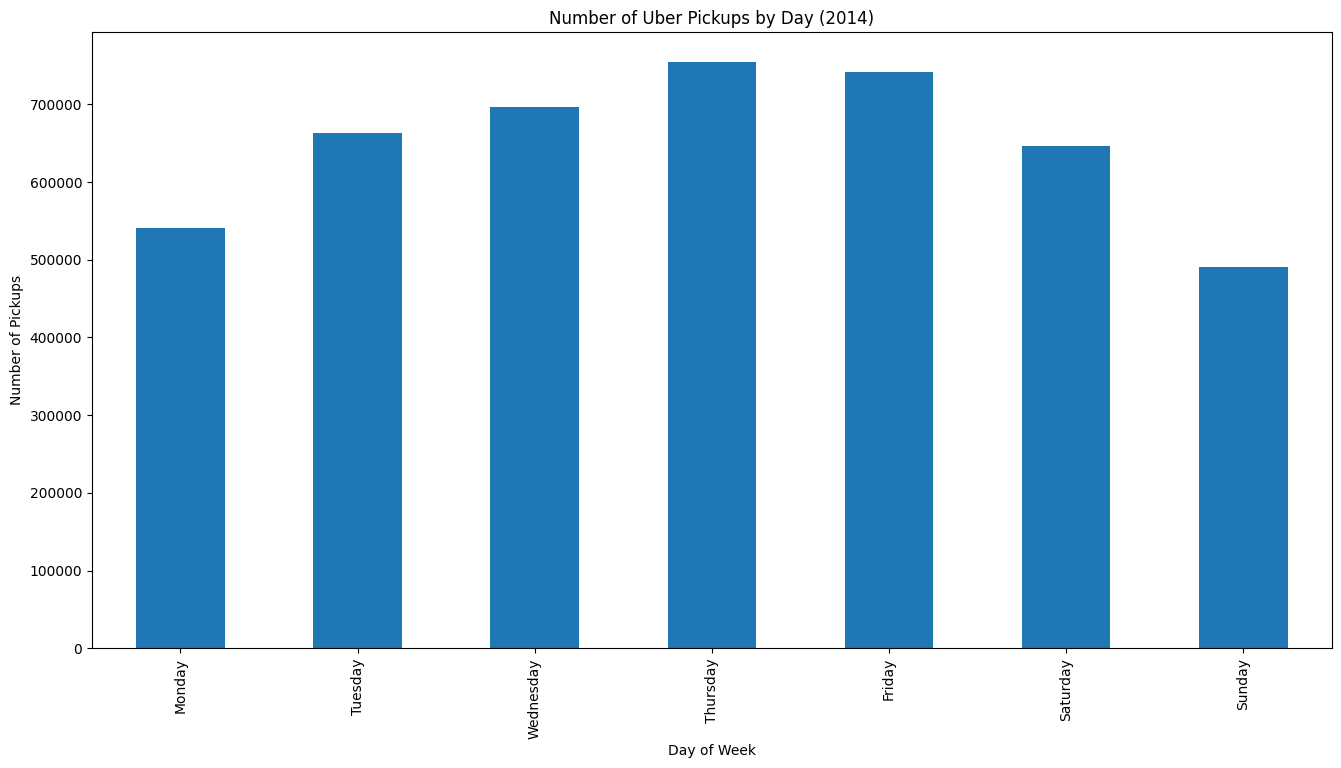

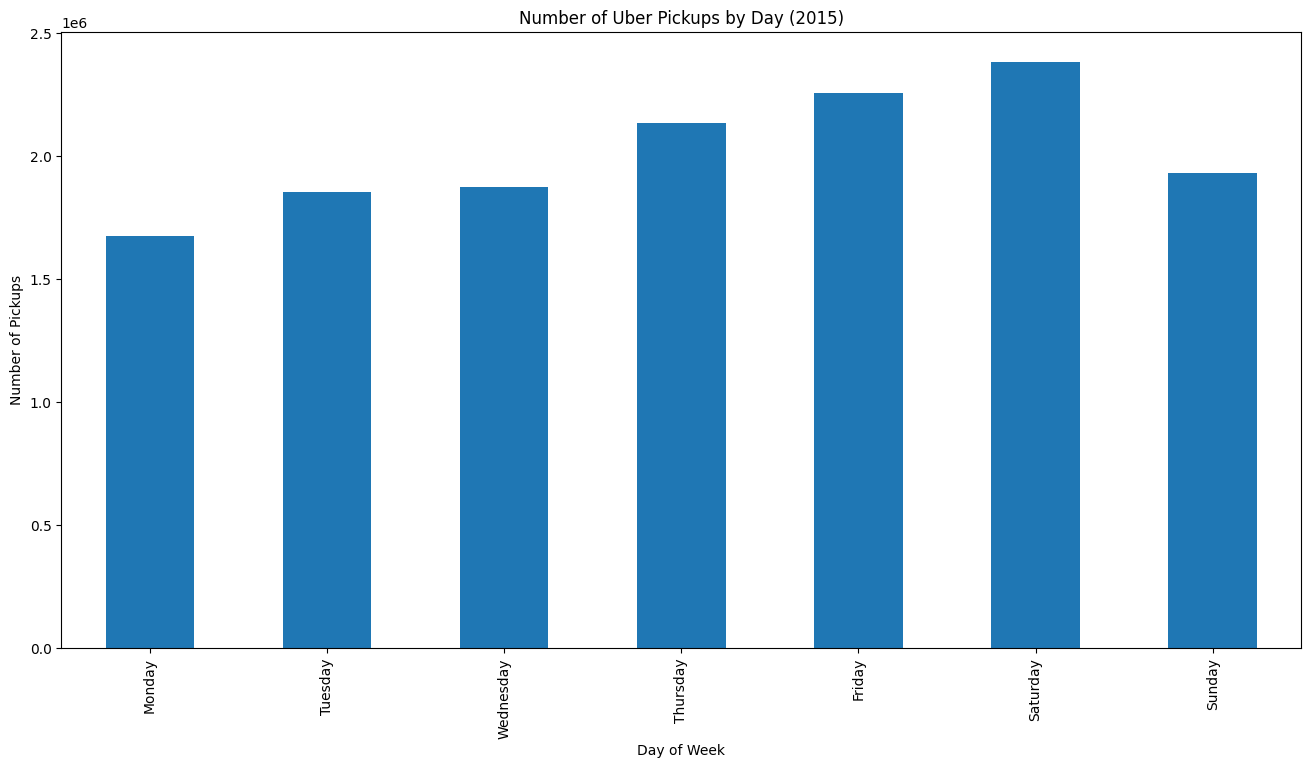

In [ ]:
# 1. Create daily aggregations
daily_rides_2014 = uber_2014_pickup_data.groupby(['DayOfWeekNum', 'DayOfWeek'])['Base'].count().sort_index(level='DayOfWeekNum').droplevel(0, axis=0).rename('Rides Count')
daily_rides_2015 = uber_2015_pickup_data.groupby(['DayOfWeekNum', 'DayOfWeek'])['Affiliated_base_num'].count().sort_index(level='DayOfWeekNum').droplevel(0, axis=0).rename('Rides Count')

# 2. Display raw counts
print("2014 Daily Counts:")
display(daily_rides_2014)
print("\n2015 Daily Counts:")
display(daily_rides_2015)

# 3. Create and show plots
# 2014 Plot
daily_rides_2014.plot(
    kind='bar',
    figsize=(16,8),
    title='Number of Uber Pickups by Day (2014)',
    xlabel='Day of Week',
    ylabel='Number of Pickups'
)
plt.show()

# 2015 Plot
daily_rides_2015.plot(
    kind='bar',
    figsize=(16,8),
    title='Number of Uber Pickups by Day (2015)',
    xlabel='Day of Week',
    ylabel='Number of Pickups'
)
plt.show()


    Key Insights
    - Higher weekend rides suggest leisure travel; weekday peaks may indicate commuting patterns.

###**iii. Rides Per Hour**
    - The hours per day which had more total pickups


2014 Hourly Counts:


,Rides Count
Hour,
0,103836
1,67227
2,45865
3,48287
4,55230
5,83939
6,143213
7,193094
8,190504



2015 Hourly Counts:


,Rides Count
Hour,
0,595308
1,389955
2,257345
3,181324
4,171148
5,191484
6,285280
7,438301
8,576603


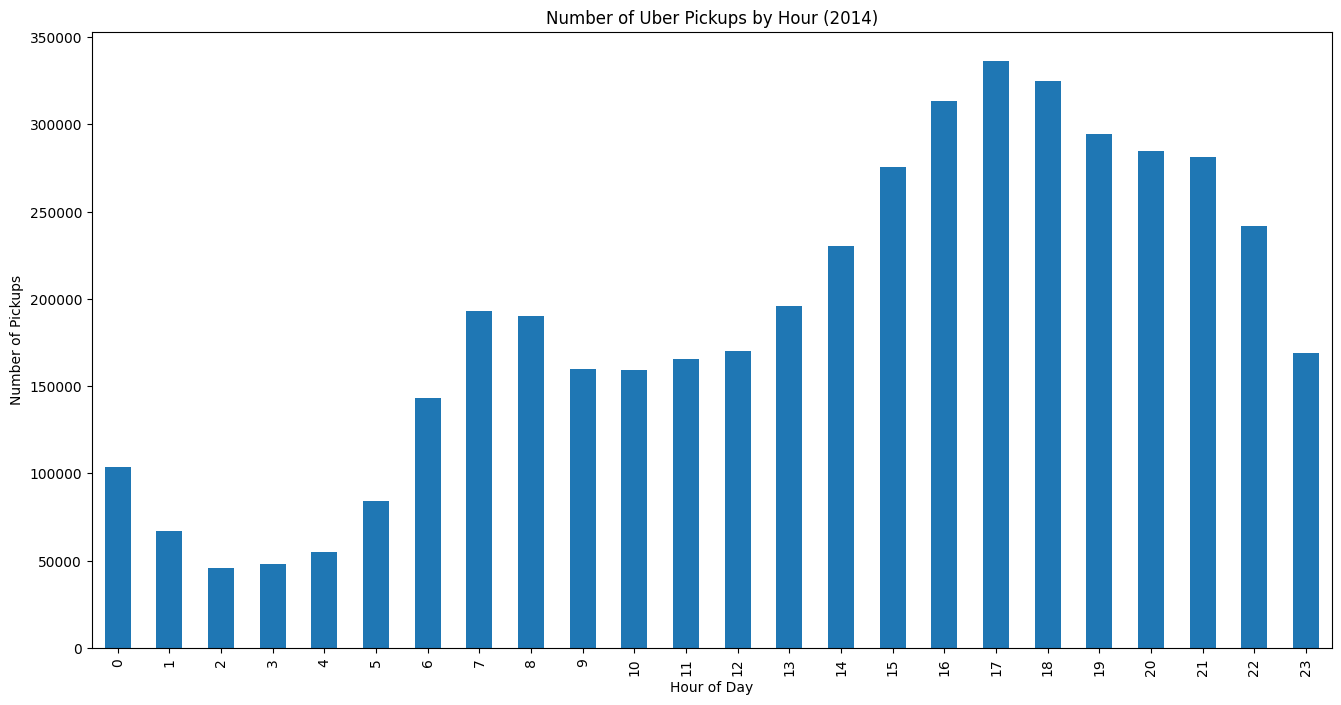

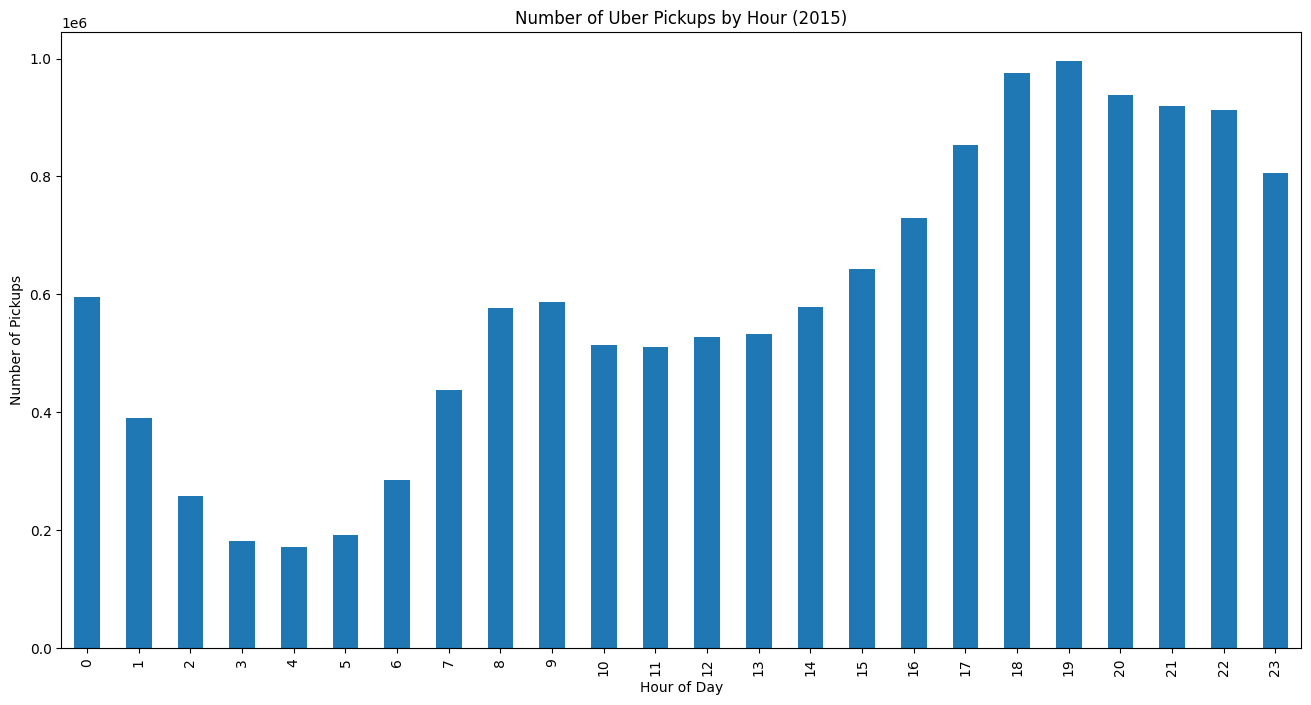

In [ ]:
# 1. Create hourly aggregations
hourly_rides_2014 = uber_2014_pickup_data.groupby('Hour')['Base'].count().rename('Rides Count')
hourly_rides_2015 = uber_2015_pickup_data.groupby('Hour')['Affiliated_base_num'].count().rename('Rides Count')

# 2. Display raw counts
print("2014 Hourly Counts:")
display(hourly_rides_2014)
print("\n2015 Hourly Counts:")
display(hourly_rides_2015)

# 3. Create and show plots
# 2014 Plot
hourly_rides_2014.plot(
    kind='bar',
    figsize=(16,8),
    title='Number of Uber Pickups by Hour (2014)',
    xlabel='Hour of Day',
    ylabel='Number of Pickups'
)
plt.show()

# 2015 Plot
hourly_rides_2015.plot(
    kind='bar',
    figsize=(16,8),
    title='Number of Uber Pickups by Hour (2015)',
    xlabel='Hour of Day',
    ylabel='Number of Pickups'
)
plt.show()

    Key Insights:
    - Morning and evening peaks indicate commuting patterns.
    - Late-night peaks suggest leisure activity.

###**iv. Business Implications From Temporal Analysis**

**1. Dynamic Pricing**
- Implement surge pricing during peak hours to balance supply and demand.

**2. Resource Management**
- Optimize driver scheduling to ensure adequate availability during high-demand periods.  
- Allocate support staff efficiently to handle customer queries.

**3. Strategic Planning**
- Time marketing campaigns to align with periods of increased customer activity.  
- Identify key focus areas for service improvement based on demand patterns.

**4. Customer Experience**
- Enhance availability during peak times to improve accessibility.  
- Reduce wait times by employing predictive positioning of drivers.

---

#**4. Algorithmic EDA: Clustering**


##**a. Data Preprocessing**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

##**b. K-Means Clustering**

    Key Concepts
    - Centroids: Represent the average location of each cluster.
    - Inertia: Measures clustering quality (lower is better).
    - Elbow Method: Identifies the optimal number of clusters.

## **(i) Clustering for a Single Value of K**

    Steps:
    - Normalize latitude and longitude.
    - Perform clustering for K=7.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select covariates for clustering
uber_2014_pickup_data_covariates = uber_2014_pickup_data[['Lat', 'Lon']]

# Normalize the covariates using z-score standardization
scaler = StandardScaler()
uber_2014_pickup_data_covariates_normalized = scaler.fit_transform(uber_2014_pickup_data_covariates)

# Verify normalization
print("Mean (normalized):", np.mean(uber_2014_pickup_data_covariates_normalized, axis=0))
print("Std Dev (normalized):", np.std(uber_2014_pickup_data_covariates_normalized, axis=0))

# Define a single K value for clustering
K = 7

# Instantiate the KMeans algorithm
k_means = KMeans(
    n_clusters=K,
    random_state=42,
)

# Fit the KMeans model on normalized data
k_means.fit(uber_2014_pickup_data_covariates_normalized)

# Get normalized cluster centers
cluster_centers_normalized = pd.DataFrame(
    k_means.cluster_centers_, columns=['Lat_norm', 'Lon_norm']
)

# Unnormalize cluster centers back to original scale
cluster_centers_original = scaler.inverse_transform(cluster_centers_normalized)
cluster_centers_original = pd.DataFrame(cluster_centers_original, columns=['Latitude', 'Longitude'])

# Calculate inertia and average inertia
inertia = k_means.inertia_
average_inertia = inertia / K

# Create the DataFrame
inertia_df = pd.DataFrame({
    'Inertia': [inertia],
    'Average Inertia': [average_inertia]
}, index = [K])

inertia_df.index.name = 'K'

# Display the DataFrame
display(inertia_df)

# Assign cluster labels to the original dataset
uber_2014_pickup_data['Cluster'] = k_means.labels_

# Display the updated original dataset as a DataFrame
display(uber_2014_pickup_data.head())

# Display centroids for the current K value
print(f'\nCentroids for K={K}:')
print(cluster_centers_original)




Mean (normalized): [ 2.84740677e-13 -1.04960248e-13]
Std Dev (normalized): [1. 1.]


,Inertia,Average Inertia
K,,
7,2.297353e+06,328193.278559


,Date/Time,Lat,Lon,Base,Date,Time,Month,Week,DayOfMonthNum,DayOfWeekNum,DayOfWeek,Hour,Cluster
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,2014-04-01,00:11:00,4,14,1,1,Tuesday,0,1
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,2014-04-01,00:17:00,4,14,1,1,Tuesday,0,3
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,2014-04-01,00:21:00,4,14,1,1,Tuesday,0,3
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,2014-04-01,00:28:00,4,14,1,1,Tuesday,0,1
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,2014-04-01,00:33:00,4,14,1,1,Tuesday,0,1



Centroids for K=7:
    Latitude  Longitude
0  40.659815 -73.765556
1  40.756576 -73.980574
2  40.696259 -74.203403
3  40.725828 -73.995012
4  40.791486 -73.956902
5  40.788625 -73.853372
6  40.676501 -73.966375


    Folium is used to plot the centroids on a map, which can be useful for location-based insights.

In [ ]:
from matplotlib import cm
import folium

# For consistent map center
map_center = [uber_2014_pickup_data['Lat'].mean(), uber_2014_pickup_data['Lon'].mean()]

# Extract cluster centroids as coordinates
centroid_coords = cluster_centers_original[['Latitude', 'Longitude']].values.tolist()

# Create a Folium map
map_ = folium.Map(location=map_center, zoom_start=11)

# Add markers for each cluster centroid
for center in centroid_coords:
    folium.Marker(location=center, popup=str(center)).add_to(map_)

print("Single K Map Visualization:")
display(map_)

Single K Map Visualization:


    Key Insights:
    1. Cluster Centroids:
      - Represent the average pickup locations for each cluster.
      - Highlight high-demand areas such as airports, business hubs, and residential neighborhoods.

    2. Operational Use:
      - Cluster centroids can guide driver allocation and improve ride-matching efficiency.
      - Visualizing monthly or time-specific clusters helps adapt to seasonal or temporal changes in demand.

## **(ii) Clustering for multiple values of K**
    - Performed clustering for  K [2, 3, 5, 7, 9, 12, 16].
    - Used the Elbow Method to determine optimal K.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

###############################################################
# Step 1: Data Preparation - Normalize Latitude and Longitude
###############################################################
# Select covariates for clustering
uber_2014_pickup_data_covariates = uber_2014_pickup_data[['Lat', 'Lon']]

# Normalize the covariates using z-score standardization
scaler = StandardScaler()
uber_2014_pickup_data_covariates_normalized = scaler.fit_transform(uber_2014_pickup_data_covariates)

# Verify normalization
print("Mean (normalized):", np.mean(uber_2014_pickup_data_covariates_normalized, axis=0))
print("Std Dev (normalized):", np.std(uber_2014_pickup_data_covariates_normalized, axis=0))

###############################################################
# Step 2: Define K values for clustering
###############################################################
K = [2, 3, 5, 7, 9, 12, 16]

# Initialize a list to store inertia results
inertia_df_list = []

###############################################################
# Step 3: Perform K-Means Clustering
###############################################################
for k in K:
    ###########################################################
    # Part 1: Fit K-Means and Compute Cluster Centers
    ###########################################################
    # Instantiate the KMeans algorithm
    k_means = KMeans(
        n_clusters=k,
        random_state=42,
    )

    # Fit the KMeans model on normalized data
    k_means.fit(uber_2014_pickup_data_covariates_normalized)

    # Get normalized cluster centers
    cluster_centers_normalized = k_means.cluster_centers_

    # Unnormalize cluster centers back to original scale
    cluster_centers_original = scaler.inverse_transform(cluster_centers_normalized)
    cluster_centers_original = pd.DataFrame(cluster_centers_original, columns=['Latitude', 'Longitude'])

    # Display centroids for the current K value
    print(f'\nCentroids for K={k}:')
    print(cluster_centers_original)

    ###########################################################
    # Part 2: Compute Inertia and Average Inertia
    ###########################################################
    # Calculate inertia and average inertia
    inertia = k_means.inertia_
    average_inertia = inertia / k

    # Append inertia results for this K value
    inertia_df_list.append(pd.DataFrame({
        'K': [k],
        'Inertia': [inertia],
        'Average Inertia': [average_inertia]
    }))

###############################################################
# Step 4: Combine Inertia Results into a Single DataFrame
###############################################################
# Concatenate all the DataFrames
inertia_df = pd.concat(inertia_df_list, axis=0).set_index('K')

# Display the final Inertia DataFrame
print("\nInertia Results:")
print(inertia_df)


Mean (normalized): [ 2.84740677e-13 -1.04960248e-13]
Std Dev (normalized): [1. 1.]

Centroids for K=2:
    Latitude  Longitude
0  40.672094 -73.884801
1  40.746341 -73.982318

Centroids for K=3:
    Latitude  Longitude
0  40.672448 -73.886911
1  40.747061 -73.979863
2  40.695842 -74.200806

Centroids for K=5:
    Latitude  Longitude
0  40.662785 -73.770744
1  40.757436 -73.980714
2  40.694480 -74.202492
3  40.710917 -73.987505
4  40.804510 -73.892431

Centroids for K=7:
    Latitude  Longitude
0  40.659815 -73.765556
1  40.756576 -73.980574
2  40.696259 -74.203403
3  40.725828 -73.995012
4  40.791486 -73.956902
5  40.788625 -73.853372
6  40.676501 -73.966375

Centroids for K=9:
    Latitude  Longitude
0  40.710572 -73.948090
1  40.766129 -73.973627
2  40.885823 -73.889861
3  40.730411 -73.997854
4  40.764402 -73.866377
5  40.668704 -73.977807
6  40.658898 -73.762176
7  40.804708 -74.302539
8  40.685295 -74.189571

Centroids for K=12:
     Latitude  Longitude
0   40.711509 -73.946629
1 

**Finding Optimal Number of Clusters (Elbow Method)**


    The Elbow Method is a technique used to determine the optimal number of clusters K for K-Means clustering. It evaluates the inertia (sum of squared distances between data points and their assigned cluster centroids) for various values of K.

    - How It Works:
      - Inertia decreases as K increases because clusters become smaller and more tightly grouped.
      - The optimal K is identified at the "elbow" point on the inertia vs. K graph, where the rate of decrease in inertia slows significantly.
  

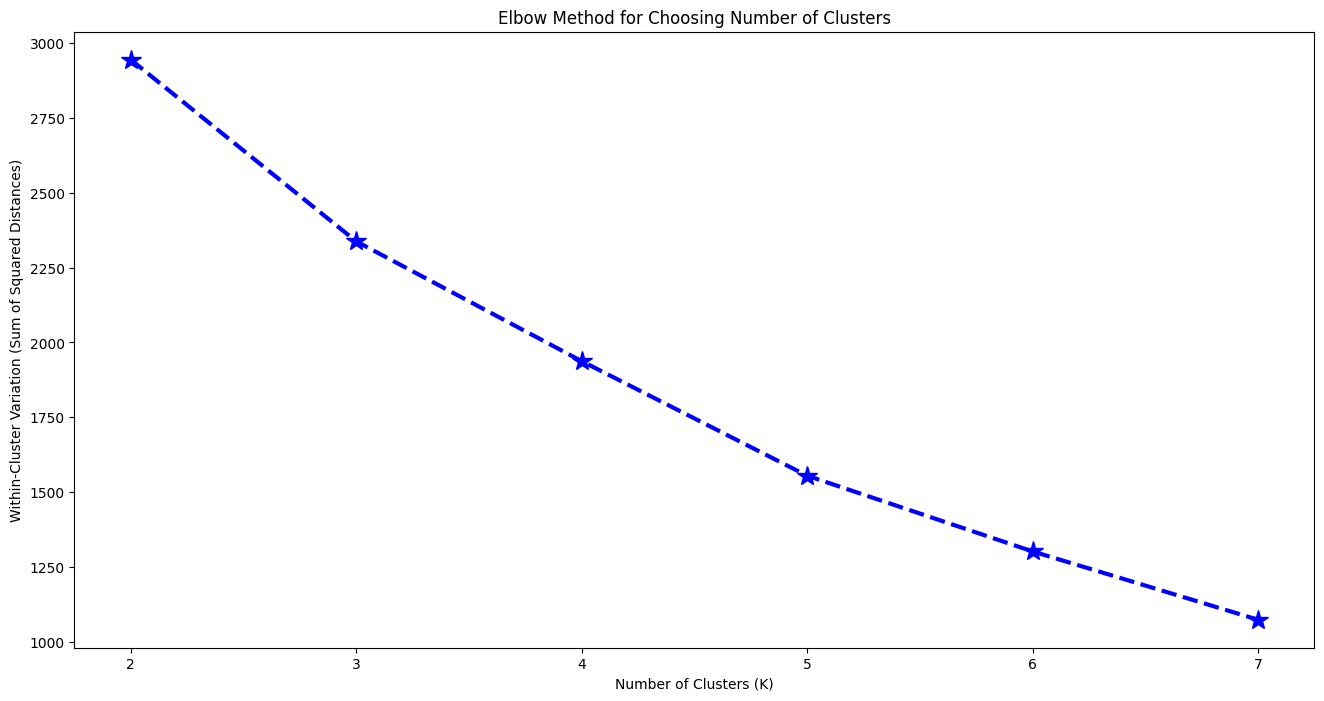

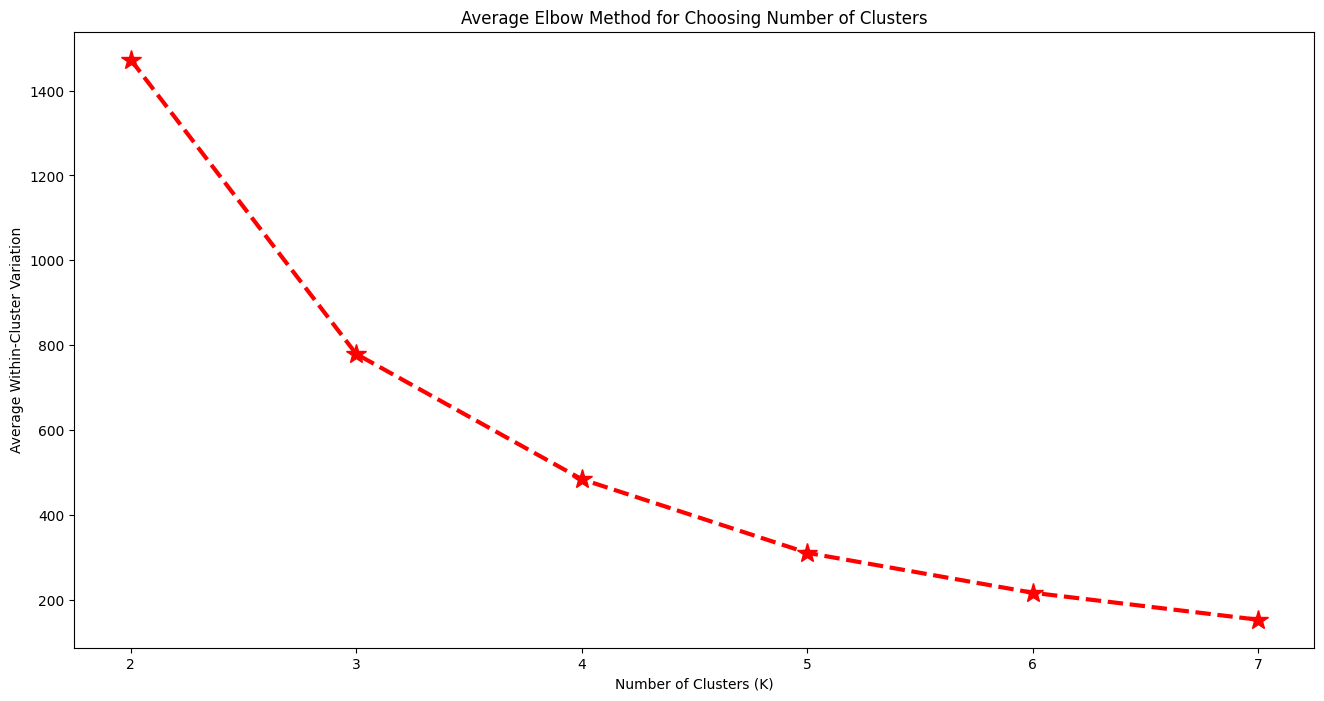

In [ ]:
# Create the Elbow Graph for Within-cluster Sum of Squared Distances (Inertia)
plt.figure(figsize=(16, 8))
inertia['Inertia'].plot(marker='*', markersize=15, linewidth=3, color='blue', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Variation (Sum of Squared Distances)')
plt.title('Elbow Method for Choosing Number of Clusters')
plt.show()

# Create the Elbow Graph for Average Inertia per Cluster
plt.figure(figsize=(16, 8))
inertia['Average Cluster Inertia'].plot(marker='*', markersize=15, linewidth=3, color='red', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Average Within-Cluster Variation')
plt.title('Average Elbow Method for Choosing Number of Clusters')
plt.show()


**Optimal K**

In [ ]:
# Find the Optimal K (the point of minimum average cluster inertia)
optimal_K = K_hyperparameters[inertia['Average Cluster Inertia'].argmin()]
print(f"Optimal number of clusters (K) by Elbow method: {optimal_K}")

Optimal number of clusters (K) by Elbow method: 7


    Key Insights:
      - The "elbow" point balances model complexity and clustering quality, providing the most meaningful division of data into clusters.


---

#**5. Correlation Analysis**
    - Objective: Analyze hourly trip correlations through a heatmap of hourly correlations.

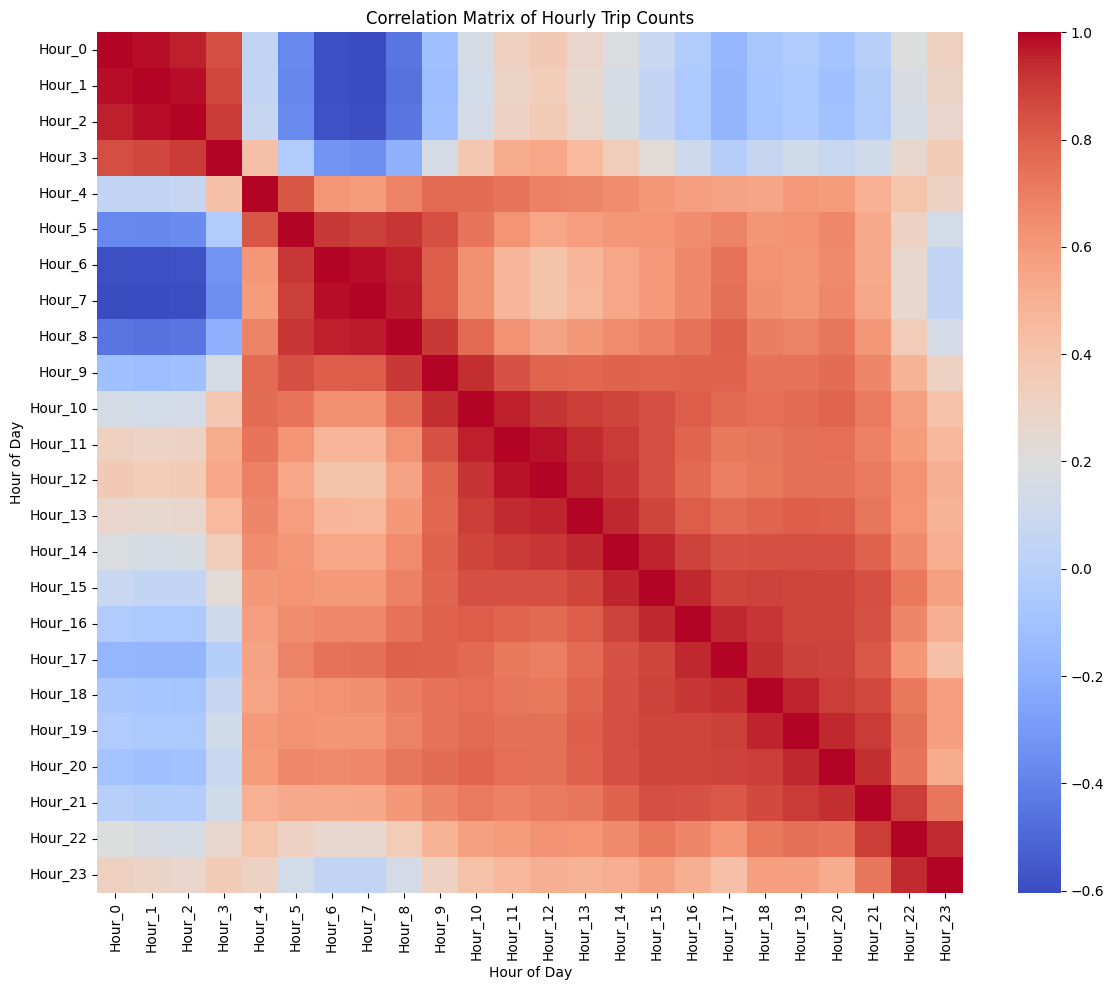

In [ ]:
# Correlation Analysis Between Hourly Trip Counts
# Temporal correlation analysis for hourly trip counts across the day

# Calculate daily hourly trips
daily_hourly_trips = uber_2014_pickup_data.groupby(['Date', 'Hour'])['Base'].count().reset_index(name='TripCount')

# Reshape data for correlation matrix
hourly_data = daily_hourly_trips.set_index(['Date', 'Hour']).unstack(level='Hour')
hourly_data.columns = [f'Hour_{int(hour)}' for hour in hourly_data.columns.get_level_values(1)]

# Compute correlation matrix
correlation_matrix = hourly_data.corr()

# Visualize the correlation matrix
import seaborn as sns
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.title('Correlation Matrix of Hourly Trip Counts')
plt.xlabel('Hour of Day')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.show()

    Key Insights:
    - Strong positive correlations are observed between adjacent hours, indicating consistent trip volumes or gradual transitions.
    - Negative correlations exist between early morning hours (0-6) and peak hours (15-23), reflecting contrasting activity patterns.


---

#**6. Linear Regression Analysis**

    Objective
    - To identify significant predictors of trip counts using statistical regression analysis.

    Approach
    1. Dummy Encoding:
      - `DayOfWeek` and `Month` were converted into dummy variables to represent categorical data.
      - Dummy encoding helps capture categorical effects (e.g., specific days or months) while avoiding issues like multicollinearity.

    2. Regression Methodology:
      - Performed Ordinary Least Squares (OLS) regression to analyze relationships between predictors and trip counts.
      - Regression analysis quantifies how each day of the week and month influences trip demand.

    3. Significance Testing:
      - Coefficients and p-values identify predictors that have a statistically significant impact on trip demand.


In [ ]:
# Linear Regression Analysis of Trip Counts

# Encode categorical variables for regression analysis
day_dummies = pd.get_dummies(daily_trips['DayOfWeek'], drop_first=True)
month_dummies = pd.get_dummies(daily_trips['Month'], prefix='Month', drop_first=True)

# Combine dummy variables with the original dataset
daily_trips = pd.concat([daily_trips, day_dummies, month_dummies], axis=1)

# Prepare regression inputs
Y = daily_trips['TripCount']
dummy_cols = day_dummies.columns.tolist() + month_dummies.columns.tolist()
X = daily_trips[dummy_cols].astype(int)

# Add a constant to the model
import statsmodels.api as sm
X = sm.add_constant(X)

# Fit the linear regression model
model = sm.OLS(Y, X).fit()

# Display regression summary
print(model.summary())



                            OLS Regression Results                            
Dep. Variable:              TripCount   R-squared:                       0.765
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     50.53
Date:                Fri, 13 Dec 2024   Prob (F-statistic):           6.11e-48
Time:                        09:18:13   Log-Likelihood:                -1748.5
No. Observations:                 183   AIC:                             3521.
Df Residuals:                     171   BIC:                             3560.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.255e+04    915.019     24.645      0.0

    Key Insights:
      - Certain days (e.g., Fridays) and months (e.g., July) significantly influence trip counts.
      - Coefficients indicate the relative impact of these predictors.

---

# **7. Conclusion**

**Key Findings**
1. Peak Demand:
   - Highest trip activity occurs during rush hours and weekends, reflecting commuter and leisure travel patterns.

2. Popular Locations:
   - Airports and business districts consistently dominate as key pickup hubs, highlighting their role in urban mobility.

**Clustering Utility**
- Clustering centroids provide actionable insights for optimizing Uber’s resource allocation, enabling better driver coverage in high-demand areas.
- By treating centroids as operational hubs, Uber can improve efficiency in ride matching and reduce rider wait times.


**Future Work**
- Predictive Models:
   - Integrate clustering results with time-series data to develop dynamic predictive models for demand forecasting.
- Time-Sensitive Clustering:
   - Explore time-of-day-specific clustering to account for changing demand patterns throughout the day.
